In [2]:
"""
Componentes conectados y propiedades de región
Este notebook presenta el etiquetado de componentes conectados y las mediciones basadas en regiones en imágenes binarias.
Tras el thresholding y la morphological clean up, el siguiente paso en muchos procesos de segmentación es identificar objetos individuales y cuantificar sus propiedades.
Objetivos de aprendizaje
- Comprender el etiquetado de componentes conectados
- Separar una máscara binaria en regiones individuales
- Medir propiedades de región como área, centroide, cuadro delimitador y descriptores de forma
- Visualizar regiones etiquetadas
- Convertir objetos segmentados en datos cuantitativos
Contexto de imagen de objetos
Los componentes conectados y las propiedades de región son esenciales en la imagen para:
- Conteo de partículas
- Análisis de poros
- Medición de la distribución de tamaño
- Filtrado de objetos
- Extracción de características para aprendizaje automático
"""

'\nComponentes conectados y propiedades de región\nEste notebook presenta el etiquetado de componentes conectados y las mediciones basadas en regiones en imágenes binarias.\nTras el thresholding y la morphological clean up, el siguiente paso en muchos procesos de segmentación es identificar objetos individuales y cuantificar sus propiedades.\nObjetivos de aprendizaje\n- Comprender el etiquetado de componentes conectados\n- Separar una máscara binaria en regiones individuales\n- Medir propiedades de región como área, centroide, cuadro delimitador y descriptores de forma\n- Visualizar regiones etiquetadas\n- Convertir objetos segmentados en datos cuantitativos\nContexto de imagen de objetos\nLos componentes conectados y las propiedades de región son esenciales en la imagen para:\n- Conteo de partículas\n- Análisis de poros\n- Medición de la distribución de tamaño\n- Filtrado de objetos\n- Extracción de características para aprendizaje automático\n'

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import data, filters, morphology, measure, color, segmentation, util
from skimage.draw import disk

In [4]:
def show_image(image, title="", cmap="gray", save_path=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def compare_images(images, titles, cmap="gray", figsize=(15, 5), save_path=None):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


def save_dataframe_csv(df, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    df.to_csv(save_path, index=False)

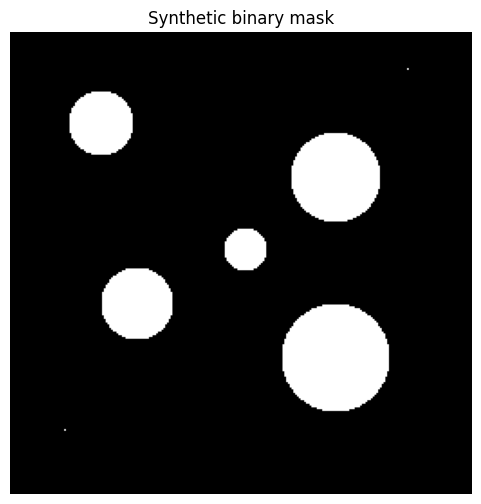

In [5]:
mask = np.zeros((256, 256), dtype=bool)

objects = [
    ((50, 50), 18),
    ((80, 180), 25),
    ((150, 70), 20),
    ((180, 180), 30),
    ((120, 130), 12),
]

for center, radius in objects:
    rr, cc = disk(center, radius, shape=mask.shape)
    mask[rr, cc] = True

# Small noisy objects
mask[20, 220] = True
mask[220, 30] = True

show_image(
    mask,
    "Synthetic binary mask",
    #save_path="../figures/figures_connected_components/synthetic_binary_mask.png"
)

Number of labeled objects: 7


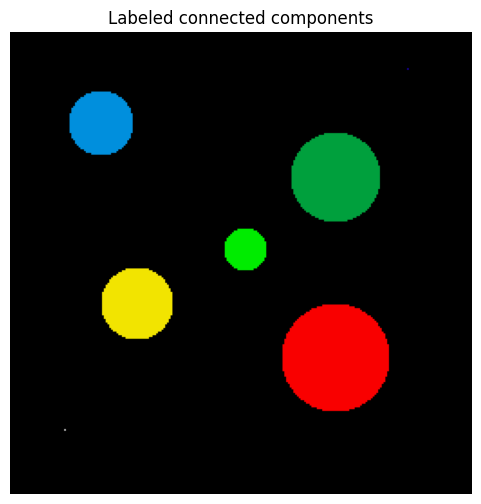

In [7]:
labeled_mask = measure.label(mask, connectivity=2)

print(f"Number of labeled objects: {labeled_mask.max()}")

show_image(
    labeled_mask,
    "Labeled connected components",
    cmap="nipy_spectral",
    save_path="../figures/figures_connected_components/labeled_components.png"
)

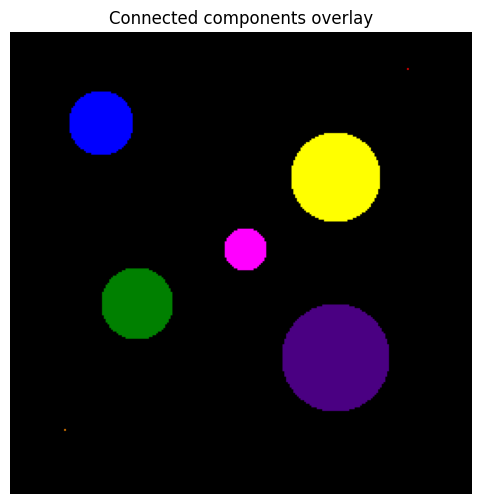

In [8]:
"""
Visualización por superposición
A menudo resulta útil visualizar objetos etiquetados con superposiciones de color en lugar de etiquetas numéricas sin formato.
"""
overlay = color.label2rgb(labeled_mask, bg_label=0)

show_image(
    overlay,
    "Connected components overlay",
    cmap=None,
    save_path="../figures/figures_connected_components/connected_components_overlay.png"
)

In [11]:
"""
Medición de las propiedades de una región
Una vez etiquetados los objetos, podemos extraer sus propiedades geométricas y basadas en la intensidad.
Algunas propiedades importantes de una región incluyen:
- Área
- Centroide
- Caja delimitadora
- Diámetro equivalente
- Excentricidad
- Perímetro
- Solidez
"""
regions = measure.regionprops(labeled_mask)

print(f"numero de regiones medidas: {len(regions)}")
print("\nPropiedades del primer objeto:")

first_region = regions[0]
y, x = first_region.centroid
print(f"Label: {first_region.label}")
print(f"Area: {first_region.area}")
#print(f"Centroid: {first_region.centroid}")
print(f"Centroid (row, col): ({y:.2f}, {x:.2f})")
print(f"Bounding box: {first_region.bbox}")
print(f"Equivalent diameter: {first_region.equivalent_diameter_area:.2f}")
print(f"Eccentricity: {first_region.eccentricity:.4f}")
print(f"Perimeter: {first_region.perimeter:.2f}")
print(f"Solidity: {first_region.solidity:.4f}")

numero de regiones medidas: 7

Propiedades del primer objeto:
Label: 1
Area: 1.0
Centroid (row, col): (20.00, 220.00)
Bounding box: (20, 220, 21, 221)
Equivalent diameter: 1.13
Eccentricity: 0.0000
Perimeter: 0.00
Solidity: 1.0000


In [12]:
props_table = measure.regionprops_table(
    labeled_mask,
    properties=[
        "label",
        "area",
        "centroid",
        "bbox",
        "equivalent_diameter",
        "eccentricity",
        "perimeter",
        "solidity"
    ]
)

df_props = pd.DataFrame(props_table)
df_props

,label,area,centroid-0,centroid-1,bbox-0,bbox-1,bbox-2,bbox-3,equivalent_diameter,eccentricity,perimeter,solidity
0,1,1.0,20.0,220.0,20,220,21,221,1.128379,0.0,0.000000,1.000000
1,2,1005.0,50.0,50.0,33,33,68,68,35.771577,0.0,114.911688,0.984329
2,3,1941.0,80.0,180.0,56,156,105,205,49.712754,0.0,161.539105,0.983781
3,4,437.0,120.0,130.0,109,119,132,142,23.588253,0.0,73.941125,0.982022
4,5,1245.0,150.0,70.0,131,51,170,90,39.814360,0.0,128.568542,0.981087
5,6,2809.0,180.0,180.0,151,151,210,210,59.804096,0.0,194.509668,0.988736
6,7,1.0,220.0,30.0,220,30,221,31,1.128379,0.0,0.000000,1.000000


In [13]:
save_dataframe_csv(
    df_props,
    "../figures/figures_connected_components/region_properties_table.csv"
)

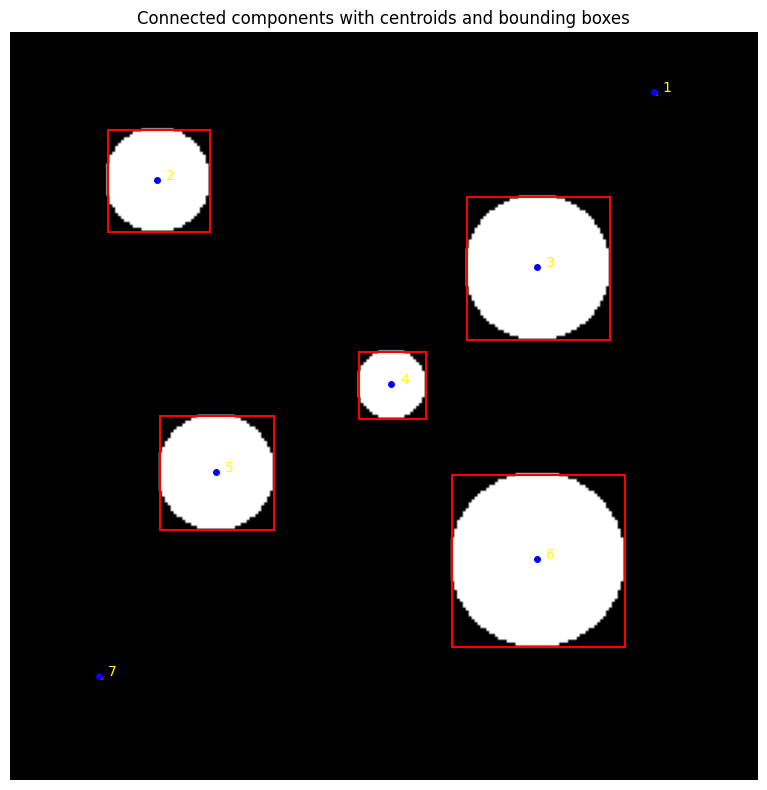

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(mask, cmap="gray")
ax.set_title("Connected components with centroids and bounding boxes")
ax.axis("off")

for region in regions:
    minr, minc, maxr, maxc = region.bbox
    y0, x0 = region.centroid

    rect = plt.Rectangle(
        (minc, minr),
        maxc - minc,
        maxr - minr,
        fill=False,
        edgecolor="red",
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.plot(x0, y0, "bo", markersize=4)
    ax.text(x0 + 3, y0, str(region.label), color="yellow", fontsize=10)

plt.tight_layout()
#os.makedirs("../figures/figures_connected_components", exist_ok=True)
plt.savefig(
    "../figures/figures_connected_components/centroids_bounding_boxes.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()